# Exploration de dataset et visualisation d'évolution temporelle

# Ouverture et exploration

In [ ]:
import pandas as pd 
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt 

# Configuration globale de typographie
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['American Typewriter']
plt.rcParams.update({'font.size': 14}) # Taille de base pour tout

ds = xr.open_dataset('/Users/arnoldkono/Downloads/cmems_mod_ibi_wav_my_0.027deg_PT1H-i_1778266648705.nc')
ds

<xarray.Dataset> Size: 403MB
Dimensions:    (time: 704, latitude: 224, longitude: 213)
Coordinates:
  * time       (time) datetime64[ns] 6kB 2025-11-01T05:00:00 ... 2025-11-30T1...
  * latitude   (latitude) float32 896B 42.28 42.31 42.33 ... 48.42 48.45 48.47
  * longitude  (longitude) float32 852B -5.666 -5.638 -5.611 ... 0.195 0.2228
Data variables:
    VMDR_WW    (time, latitude, longitude) float32 134MB ...
    VTM01_WW   (time, latitude, longitude) float32 134MB ...
    VHM0_WW    (time, latitude, longitude) float32 134MB ...
Attributes:
    Conventions:       CF-1.11
    title:             CMEMS IBI MULTI-YEAR REANALYSIS: HOURLY WAVE PRODUCTS
    institution:       NOWSystems-MeteoFrance
    source:            MFWAM-CY47R1
    contact:           https://marine.copernicus.eu/contact
    references:        http://marine.copernicus.eu/
    comment:           
    subset:source:     ARCO data downloaded from the Marine Data Store using ...
    subset:productId:  IBI_MULTIYEAR_WAV_005_006
    subset:datasetId:  cmems_mod_ibi_wav_my_0.027deg_PT1H-i_202511
    subset:date:       2026-05-08T18:57:28.705Z

## Choisir un instant donné

In [14]:

# 1. Sélectionner l'instant précis
# Vous pouvez utiliser une date formatée ou un index (ex: isel(time=0))
instant_precis = "2025-11-01T05:00:00"
data_step = ds.sel(time=instant_precis, method='nearest')

# 2. Sectionner les variables spécifiques
# Remplacez les noms entre guillemets par les noms réels dans votre fichier (ex: 'swh', 'mwp', 'mwd')
hs = data_step['VHM0_WW']
tp = data_step['VTM01_WW']
dp = data_step['VMDR_WW']

print(f"Données extraites pour l'instant : {data_step.time.values}")

Données extraites pour l'instant : 2025-11-01T05:00:00.000000000


## Visualisation de la repartition géographique

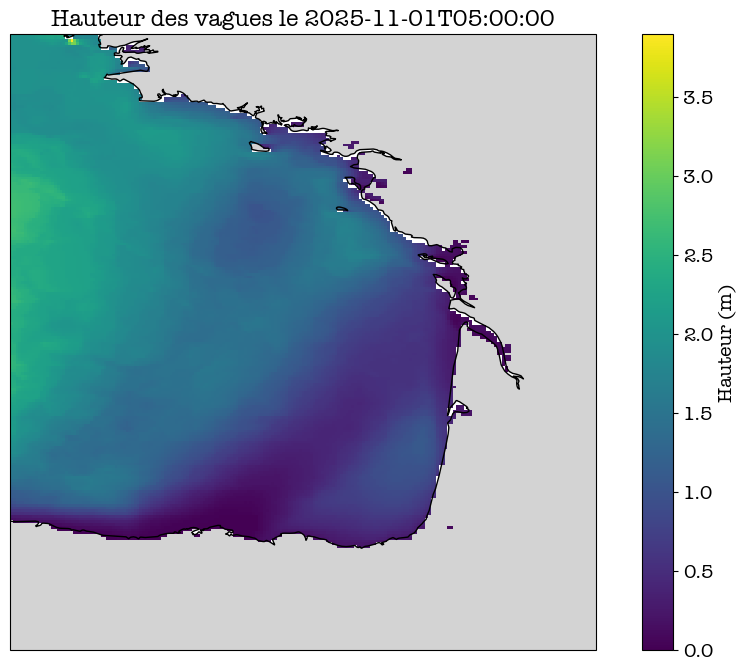

In [15]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Ajouter des éléments de carte
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.LAND, facecolor='lightgray')

# Afficher la hauteur significative (Hs)
im = hs.plot(ax=ax, x='longitude', y='latitude', transform=ccrs.PlateCarree(),
             cmap='viridis', cbar_kwargs={'label': 'Hauteur (m)'})

plt.title(f"Hauteur des vagues le {instant_precis}")
plt.show()

## Création d'une animation pour la visualisation des variation sur deux jours

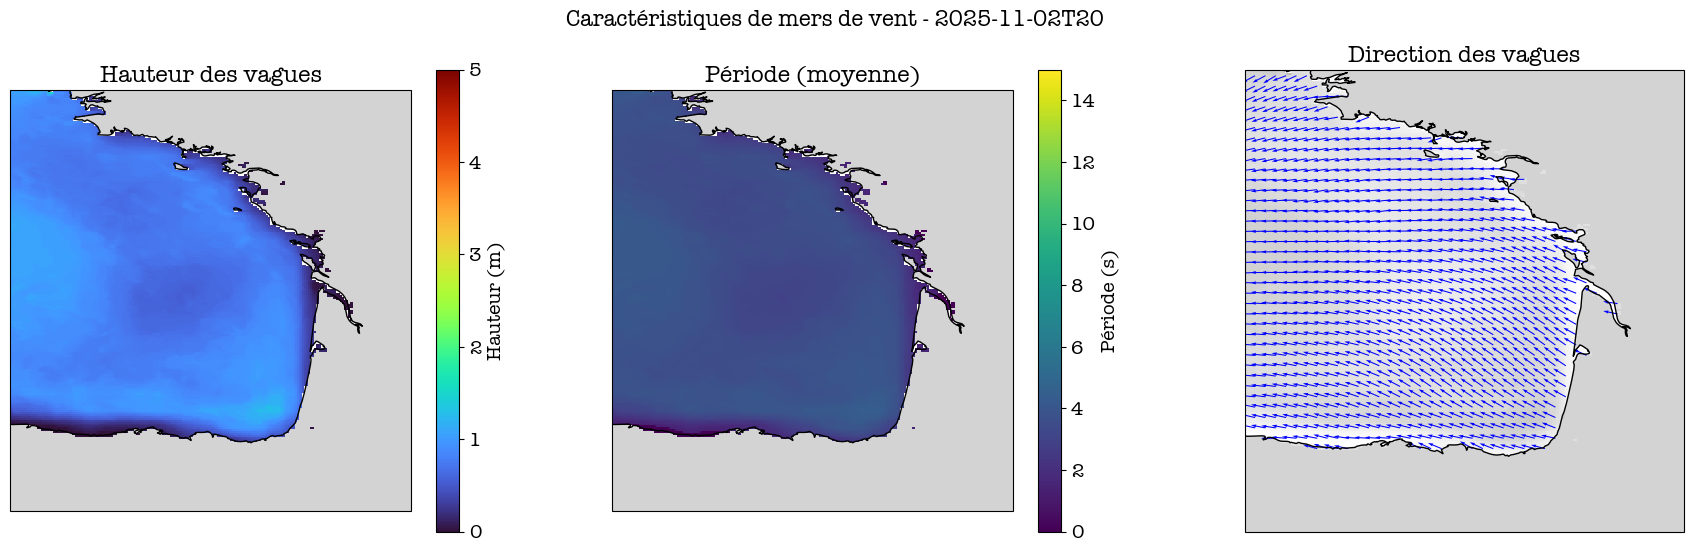

In [21]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.animation import FuncAnimation
import numpy as np

# 1. Configuration initiale de la figure
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 6), 
                                    subplot_kw={'projection': ccrs.PlateCarree()})

# On crée des variables globales pour stocker les objets graphiques
ims = []

# Initialisation des échelles (Colorbars)
# On crée des mappables "vides" pour générer les barres de couleur avant l'animation
sm1 = plt.cm.ScalarMappable(cmap='turbo', norm=plt.Normalize(vmin=0, vmax=5))
sm2 = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=0, vmax=15))

fig.colorbar(sm1, ax=ax1, orientation='vertical', pad=0.05, label='Hauteur (m)')
fig.colorbar(sm2, ax=ax2, orientation='vertical', pad=0.05, label='Période (s)')

def update(i):
    # Nettoyage des axes pour la nouvelle frame
    for ax in [ax1, ax2, ax3]:
        ax.clear()
        ax.add_feature(cfeature.COASTLINE)
        ax.add_feature(cfeature.LAND, facecolor='lightgrey')
        # On définit les limites géographiques pour éviter que la carte ne "bouge"
        ax.set_extent([ds.longitude.min(), ds.longitude.max(), ds.latitude.min(), ds.latitude.max()])

    # --- 1. Hauteur (VHM0_WW) ---
    data_hs = ds['VHM0_WW'].isel(time=i)
    im1 = data_hs.plot(ax=ax1, transform=ccrs.PlateCarree(), add_colorbar=False, 
                       cmap='turbo', vmin=0, vmax=5)
    ax1.set_title("Hauteur des vagues")

    # --- 2. Période (VTPK_WW) ---
    data_tp = ds['VTM01_WW'].isel(time=i)
    im2 = data_tp.plot(ax=ax2, transform=ccrs.PlateCarree(), add_colorbar=False, 
                       cmap='viridis', vmin=0, vmax=15)
    ax2.set_title("Période (moyenne)")

    # --- 3. Direction (VMDR_WW) ---
    # On affiche souvent la hauteur en fond atténué pour voir les flèches
    data_hs.plot(ax=ax3, transform=ccrs.PlateCarree(), add_colorbar=False, 
                 cmap='Greys', alpha=0.3)
    
    dir_deg = ds['VMDR_WW'].isel(time=i)
    # Conversion en composantes cartésiennes (U, V)
    # Attention : la convention marine est souvent 'direction vers où va la vague'
    u = np.cos(np.deg2rad(90 - dir_deg))
    v = np.sin(np.deg2rad(90 - dir_deg))
    
    skip = 5 # On ne garde qu'un point sur 5 pour la clarté
    ax3.quiver(ds.longitude[::skip], ds.latitude[::skip], 
               u[::skip, ::skip], v[::skip, ::skip], 
               transform=ccrs.PlateCarree(), color='blue', scale=30)
    ax3.set_title("Direction des vagues")

    plt.suptitle(f"Caractéristiques de mers de vent - {np.datetime_as_string(ds.time.values[i], unit='h')}", fontsize=16)
    return ax1, ax2, ax3

# Lancement de l'animation
ani = FuncAnimation(fig, update, frames=range(0, 40), interval=200, blit=False)

# Sauvegarde
ani.save('analyse_vagues_complet.gif', writer='pillow')
plt.show()